In [33]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt


url = "https://finance.yahoo.com/markets/crypto/all/"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

# 1. Listas globales en PLURAL para almacenar los resultados finales
nombres = []
precios = []
variaciones_24h = []
volumenes = []

try:
    response = requests.get(url, headers=headers)
    response.raise_for_status() 
    print("¡Conexión exitosa! Evitamos el error 403.")

    soup = BeautifulSoup(response.text, 'html.parser')
    filas = soup.select('table tbody tr')

    if not filas:
        raise ValueError("No se encontraron filas. La estructura de Yahoo Finance pudo cambiar.")

    print(f'Cacería exitosa: se encontraron {len(filas)} criptomonedas en la tabla\n')

    print("--- Analizando las primeras filas ---")
    for i, fila in enumerate(filas):
        columnas = fila.find_all('td')
        
        # Yahoo Finance tiene más de 7 columnas por fila
        if len(columnas) >= 7: 
            # 2. Variables en SINGULAR para extraer el texto de la fila actual
            nombre = columnas[1].text.strip()
            precio = columnas[3].text.strip()
            variacion = columnas[4].text.strip()  # Índice 4 es el porcentaje (Change %)
            volumen = columnas[6].text.strip()    # Índice 6 es el Volumen de 24h

            # 3. Agregamos de forma segura a las listas en PLURAL
            nombres.append(nombre)
            precios.append(precio)
            variaciones_24h.append(variacion)
            volumenes.append(volumen)

        else:
            print(f"Fila {i + 1} incompleta.")

        datos = {
            'Nombre': nombres,
            'Precios': precios,
            'Variacion_24h': variaciones_24h,
            'Volumen': volumenes
        }


except requests.exceptions.RequestException as e:
    print(f"Error de red: {e}")
except Exception as e:
    print(f"Fallo en la extracción: {e}")


df_crypto = pd.DataFrame(datos)

df_crypto

¡Conexión exitosa! Evitamos el error 403.
Cacería exitosa: se encontraron 25 criptomonedas en la tabla

--- Analizando las primeras filas ---


,Nombre,Precios,Variacion_24h,Volumen
0,Bitcoin USD,"79,168.48 -880.27 (-1.10%)",-880.27,1.589T
1,Ethereum USD,"2,487.99 -20.13 (-0.80%)",-20.13,303.513B
2,Tether USDt USD,1.00 -0.00 (-0.01%),-0.00,183.367B
3,BNB USD,738.67 -12.55 (-1.67%),-12.55,98.432B
4,XRP USD,1.39 -0.02 (-1.71%),-0.02,87.637B
5,USDC USD,1.00 -0.00 (-0.00%),-0.00,74.398B
6,Solana USD,103.79 -2.09 (-1.97%),-2.09,60.891B
7,TRON USD,0.33 -0.00 (-0.42%),-0.00,31.776B
8,Lido Staked ETH USD,"2,491.13 -16.07 (-0.64%)",-16.07,24.06B
9,Hyperliquid USD,85.17 -2.19 (-2.51%),-2.19,21.466B


In [34]:
#primero separemos el precio del porcentaje de variacion con pandas, .str.split() separa en una lista los elementos de esa columna y .str[0] toma solo el primer elemento de la lista

df_crypto['Precios'] = df_crypto['Precios'].str.split().str[0]
df_crypto['Precios'] = df_crypto['Precios'].str.replace(',', '').astype(float)
df_crypto['Variacion_24h'] = df_crypto['Variacion_24h'].astype(float)

multiplicadores = {'K': 1e3, 'M': 1e6, 'B': 1e9, 'T': 1e12}
sufijo = df_crypto['Volumen'].str[-1].str.upper()

df_crypto['Volumen'] = df_crypto['Volumen'].str.replace(r'[^\d\.]', '', regex=True).astype(float)
df_crypto['Volumen'] = df_crypto['Volumen'] * sufijo.map(multiplicadores).fillna(1)


df_crypto

,Nombre,Precios,Variacion_24h,Volumen
0,Bitcoin USD,79168.48,-880.27,1.589000e+12
1,Ethereum USD,2487.99,-20.13,3.035130e+11
2,Tether USDt USD,1.00,-0.00,1.833670e+11
3,BNB USD,738.67,-12.55,9.843200e+10
4,XRP USD,1.39,-0.02,8.763700e+10
5,USDC USD,1.00,-0.00,7.439800e+10
6,Solana USD,103.79,-2.09,6.089100e+10
7,TRON USD,0.33,-0.00,3.177600e+10
8,Lido Staked ETH USD,2491.13,-16.07,2.406000e+10
9,Hyperliquid USD,85.17,-2.19,2.146600e+10


In [35]:
df_crypto['Tendencia'] =np.where(df_crypto['Variacion_24h'] > 0, 'Alcista', 'Bajista')

df_crypto

,Nombre,Precios,Variacion_24h,Volumen,Tendencia
0,Bitcoin USD,79168.48,-880.27,1.589000e+12,Bajista
1,Ethereum USD,2487.99,-20.13,3.035130e+11,Bajista
2,Tether USDt USD,1.00,-0.00,1.833670e+11,Bajista
3,BNB USD,738.67,-12.55,9.843200e+10,Bajista
4,XRP USD,1.39,-0.02,8.763700e+10,Bajista
5,USDC USD,1.00,-0.00,7.439800e+10,Bajista
6,Solana USD,103.79,-2.09,6.089100e+10,Bajista
7,TRON USD,0.33,-0.00,3.177600e+10,Bajista
8,Lido Staked ETH USD,2491.13,-16.07,2.406000e+10,Bajista
9,Hyperliquid USD,85.17,-2.19,2.146600e+10,Bajista


In [36]:
z_variaciones_encontradas = stats.zscore(df_crypto['Variacion_24h'])
correlacion = stats.linregress(df_crypto['Precios'], df_crypto['Variacion_24h'])

r_valor = correlacion.rvalue
pendiente = correlacion.slope

print("Resultados de la regresion lineal")
print(f"Pendiente: {pendiente}")
print(f"Valor r: {r_valor}")

Resultados de la regresion lineal
Pendiente: -0.009673198193992283
Valor r: -0.9899814807074535


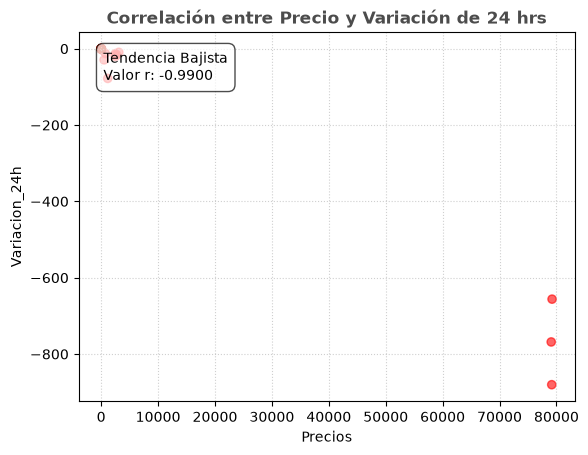

In [37]:

# Mapeamos la columna Tendencia directamente a colores
colores_puntos = np.where(df_crypto['Tendencia'] == 'Alcista', 'green', 'red')

# Le pasamos ese arreglo a Matplotlib
plt.scatter(df_crypto['Precios'], df_crypto['Variacion_24h'], color=colores_puntos, alpha=0.6)

# --- CORRECCIÓN DE PLT.TEXT ---
# Usamos transform=plt.gca().transAxes para usar coordenadas de 0 a 1 respecto al cuadro del gráfico.
# (0.05, 0.95) significa: 5% desde la izquierda, 95% desde abajo (esquina superior izquierda).
texto_resumen = f"{texto_tendencia}\nValor r: {r_valor:.4f}"
plt.text(0.05, 0.95, texto_resumen, 
         transform=plt.gca().transAxes, 
         fontsize=10, 
         verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.5'))

# 4. Etiquetas y título corregidos (eliminadas las variables libres que daban error)
plt.xlabel('Precios')
plt.ylabel('Variacion_24h')
plt.title("Correlación entre Precio y Variación de 24 hrs", alpha=0.7, fontsize=12, fontweight='bold')

plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [38]:
df_crypto.info(memory_usage='deep')


<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Nombre         25 non-null     str    
 1   Precios        25 non-null     float64
 2   Variacion_24h  25 non-null     float64
 3   Volumen        25 non-null     float64
 4   Tendencia      25 non-null     str    
dtypes: float64(3), str(2)
memory usage: 1.6 KB


In [39]:
df_crypto['Tendencia'] = df_crypto['Tendencia'].astype('category')

df_crypto.info(memory_usage='deep')



<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Nombre         25 non-null     str     
 1   Precios        25 non-null     float64 
 2   Variacion_24h  25 non-null     float64 
 3   Volumen        25 non-null     float64 
 4   Tendencia      25 non-null     category
dtypes: category(1), float64(3), str(1)
memory usage: 1.3 KB


In [40]:
df_crypto.to_parquet("dataset_financiero", engine="pyarrow", compression="snappy", partition_cols=["Tendencia"])
print("¡Archivo masivo particionado con éxito!")

¡Archivo masivo particionado con éxito!
